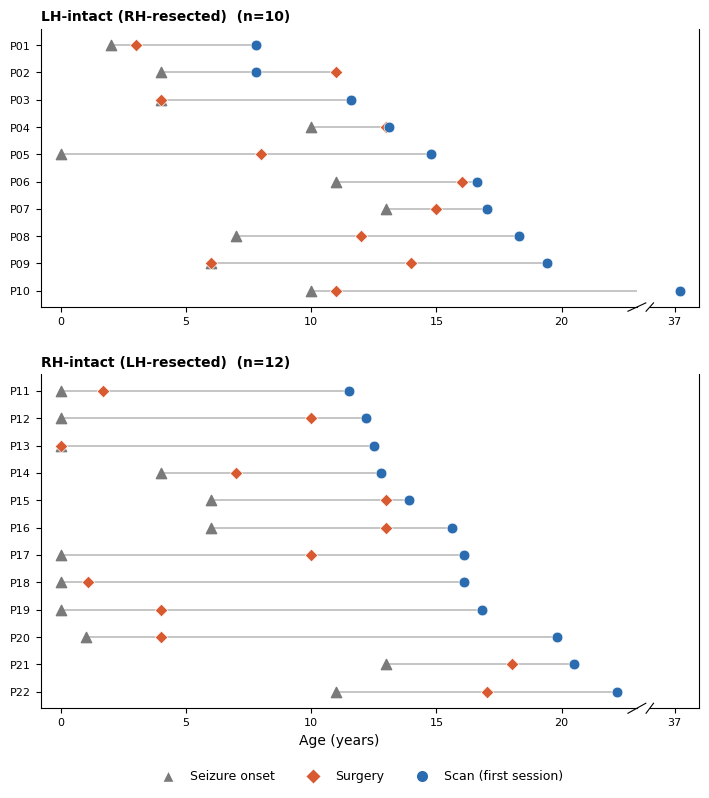

In [8]:
#!/usr/bin/env python
"""
Patient clinical timeline (Liu-style, real age axis). CORRECTED COHORT.
sub-076 reclassified RH-intact (left resection); LH=10, RH=12.
Two panels: LH-intact (RH-resected) / RH-intact (LH-resected).
Markers: seizure onset (^), surgery (D), scan = first session (o).
Broken x-axis for P10 / sub-091 (scan 37.3).
"""
import matplotlib.pyplot as plt
from matplotlib import gridspec

# (label, seizure_y, surgery_y, scan_y).  surgery_y may be a tuple (multiple ops).
LH = [  # LH-intact, by first-session scan age  (10)
    ("P01",  2.0,  3.0,  7.8),   # 077
    ("P02",  4.0, 11.0,  7.8),   # 004
    ("P03",  4.0,  4.0, 11.6),   # 075
    ("P04", 10.0, 13.0, 13.1),   # 074
    ("P05",  0.0,  8.0, 14.8),   # 008
    ("P06", 11.0, 16.0, 16.6),   # 079
    ("P07", 13.0, 15.0, 17.0),   # 039
    ("P08",  7.0, 12.0, 18.3),   # 089
    ("P09",  6.0, (6.0, 14.0), 19.4),  # 005
    ("P10", 10.0, 11.0, 37.3),   # 091
]
RH = [  # RH-intact, by first-session scan age  (12)
    ("P11",  0.0,  1.7, 11.5),   # 099
    ("P12",  0.0, 10.0, 12.2),   # 069
    ("P13",  0.0,  0.0, 12.5),   # 044
    ("P14",  4.0,  7.0, 12.8),   # 010
    ("P15",  6.0, 13.0, 13.9),   # 021
    ("P16",  6.0, 13.0, 15.6),   # 090
    ("P17",  0.0, 10.0, 16.1),   # 076  <-- moved here
    ("P18",  0.0,  1.1, 16.1),   # 108
    ("P19",  0.0,  4.0, 16.8),   # 066
    ("P20",  1.0,  4.0, 19.8),   # 092
    ("P21", 13.0, 18.0, 20.5),   # 082
    ("P22", 11.0, 17.0, 22.2),   # 078
]

C_SEIZ, C_SURG, C_SCAN = "#7A7A7A", "#D85A30", "#2B6CB0"
LINE = "#BBBBBB"
MAIN_MAX, BRK_LO, BRK_HI = 23, 35.5, 38.5

def draw_panel(ax_main, ax_brk, rows, title):
    n = len(rows)
    for i, (lab, sz, su, sc) in enumerate(rows):
        y = n - 1 - i
        su_list = [] if su is None else (list(su) if isinstance(su,(tuple,list)) else [su])
        pts = [v for v in ([sz]+su_list+[sc]) if v is not None]
        ax_main.plot([min(pts), min(max(pts), MAIN_MAX)], [y, y], color=LINE, lw=1.2, zorder=1)
        for ax in (ax_main, ax_brk):
            if sz is not None:
                ax.scatter(sz, y, marker="^", s=55, color=C_SEIZ, zorder=3)
            for sv in su_list:
                ax.scatter(sv, y, marker="D", s=42, color=C_SURG, zorder=3, edgecolors="white", linewidths=0.5)
            ax.scatter(sc, y, marker="o", s=60, color=C_SCAN, zorder=3, edgecolors="white", linewidths=0.5)
    ax_main.set_yticks(range(n)); ax_main.set_yticklabels([r[0] for r in reversed(rows)], fontsize=8)
    ax_main.set_ylim(-0.6, n-0.4); ax_main.set_xlim(-0.8, MAIN_MAX)
    ax_brk.set_xlim(BRK_LO, BRK_HI); ax_brk.set_yticks([]); ax_brk.set_ylim(-0.6, n-0.4)
    ax_main.set_title(title, fontsize=10, fontweight="bold", loc="left")
    ax_main.spines["right"].set_visible(False); ax_brk.spines["left"].set_visible(False)
    ax_brk.set_xticks([37])
    for ax in (ax_main, ax_brk):
        ax.spines["top"].set_visible(False); ax.tick_params(labelsize=8)
    d=.015; kw=dict(transform=ax_main.transAxes,color="k",clip_on=False,lw=0.8)
    ax_main.plot((1-d,1+d),(-d,d),**kw); kw.update(transform=ax_brk.transAxes); ax_brk.plot((-d*5,d*5),(-d,d),**kw)

fig = plt.figure(figsize=(8.5, 8.6))
gs = gridspec.GridSpec(2, 2, width_ratios=[12,1], height_ratios=[10,12], wspace=0.04, hspace=0.22)
axL, axLb = fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1])
axR, axRb = fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1])
draw_panel(axL, axLb, LH, "LH-intact (RH-resected)  (n=10)")
draw_panel(axR, axRb, RH, "RH-intact (LH-resected)  (n=12)")
axR.set_xlabel("Age (years)", fontsize=10)
handles = [
    plt.Line2D([],[],marker="^",color="w",markerfacecolor=C_SEIZ,ms=9,label="Seizure onset"),
    plt.Line2D([],[],marker="D",color="w",markerfacecolor=C_SURG,ms=8,label="Surgery"),
    plt.Line2D([],[],marker="o",color="w",markerfacecolor=C_SCAN,ms=9,label="Scan (first session)"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.5,-0.01))
fig.subplots_adjust(bottom=0.09)

In [6]:
import pandas as pd

# Public patient table — CORRECTED COHORT (sub-076 -> RH-intact). Figure order.
# surgery_category: "Hemispherectomy" | "Lobar resection" | "Focal resection / lesionectomy"
# No sub_bids column (kept only in the gitignored key file).
_rows = [
    # Patient, Sex, Surgery type,                      Site,                          Intact
    ("P01","F","Hemispherectomy",                "R hemisphere",                "Left"),   # 077
    ("P02","M","Lobar resection",                "R occipito-temporal",         "Left"),   # 004
    ("P03","F","Lobar resection",                "R temporal",                  "Left"),   # 075
    ("P04","F","Hemispherectomy",                "R hemisphere",                "Left"),   # 074
    ("P05","F","Hemispherectomy",                "R hemisphere",                "Left"),   # 008
    ("P06","M","Focal resection / lesionectomy", "R occipito-temporal",         "Left"),   # 079
    ("P07","F","Lobar resection",                "R temporal (anterior)",       "Left"),   # 039
    ("P08","M","Lobar resection",                "R temporo-parietal (post.)",  "Left"),   # 089
    ("P09","M","Focal resection / lesionectomy", "R parieto-occipital",         "Left"),   # 005
    ("P10","M","Hemispherectomy",                "R hemisphere",                "Left"),   # 091
    ("P11","M","Hemispherectomy",                "L hemisphere",                "Right"),  # 099
    ("P12","F","Hemispherectomy",                "L hemisphere",                "Right"),  # 069
    ("P13","M","Focal resection / lesionectomy", "L temporal",                  "Right"),  # 044
    ("P14","M","Hemispherectomy",                "L hemisphere",                "Right"),  # 010
    ("P15","F","Lobar resection",                "L parieto-occipital",         "Right"),  # 021
    ("P16","F","Hemispherectomy",                "L hemisphere",                "Right"),  # 090
    ("P17","M","Lobar resection",                "L occipito-temporal",         "Right"),  # 076
    ("P18","F","Hemispherectomy",                "L hemisphere",                "Right"),  # 108
    ("P19","M","Hemispherectomy",                "L hemisphere",                "Right"),  # 066
    ("P20","F","Hemispherectomy",                "L hemisphere",                "Right"),  # 092
    ("P21","M","Focal resection / lesionectomy", "L temporal (superior)",       "Right"),  # 082
    ("P22","F","Lobar resection",                "L temporal (anterior)",       "Right"),  # 078
]
patient_table = pd.DataFrame(_rows, columns=["Patient","Sex","Surgery type","Site","Intact"])
with pd.option_context("display.max_colwidth", None):
    display(patient_table)
# print(patient_table.to_latex(index=False))  # manuscript version

,Patient,Sex,Surgery type,Site,Intact
0,P01,F,Hemispherectomy,R hemisphere,Left
1,P02,M,Lobar resection,R occipito-temporal,Left
2,P03,F,Lobar resection,R temporal,Left
3,P04,F,Hemispherectomy,R hemisphere,Left
4,P05,F,Hemispherectomy,R hemisphere,Left
5,P06,M,Focal resection / lesionectomy,R occipito-temporal,Left
6,P07,F,Lobar resection,R temporal (anterior),Left
7,P08,M,Lobar resection,R temporo-parietal (post.),Left
8,P09,M,Focal resection / lesionectomy,R parieto-occipital,Left
9,P10,M,Hemispherectomy,R hemisphere,Left


saved /user_data/csimmon2/git_repos/sym_pt/C_results/figures/anatomy_LH_intact.png


/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/nilearn/image/resampling.py:809: UserWarning: Casting data from int32 to float32
  return resample_img(


saved /user_data/csimmon2/git_repos/sym_pt/C_results/figures/anatomy_RH_intact.png


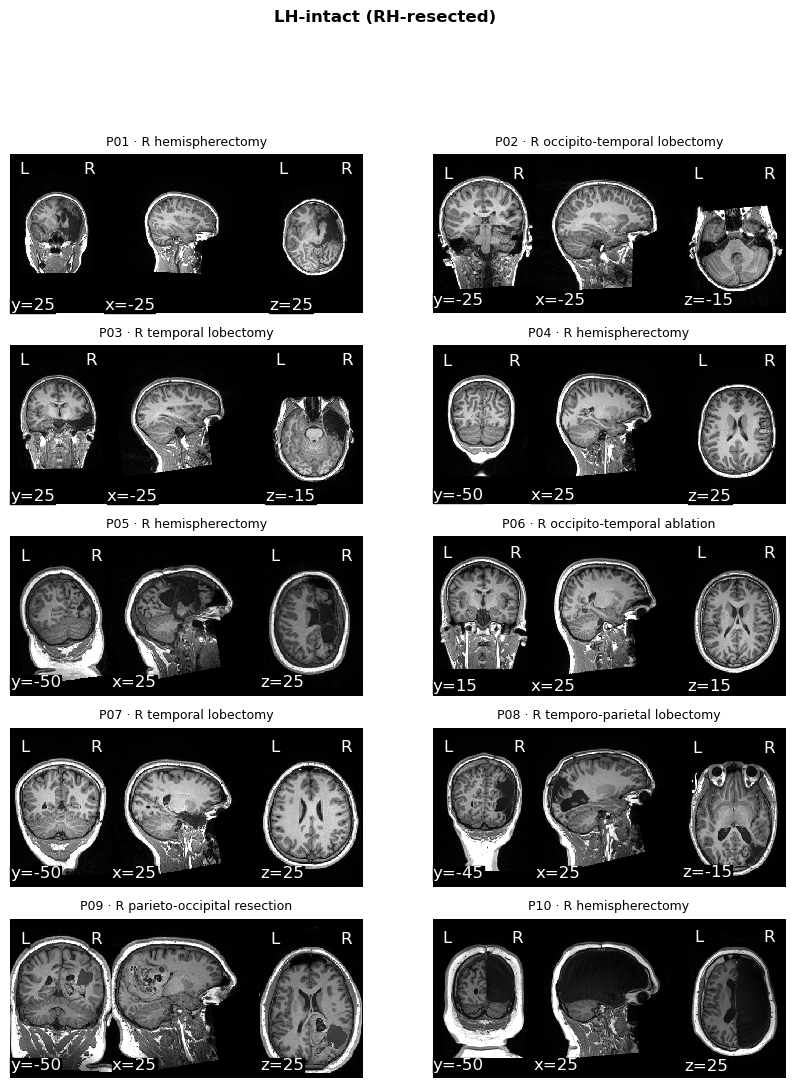

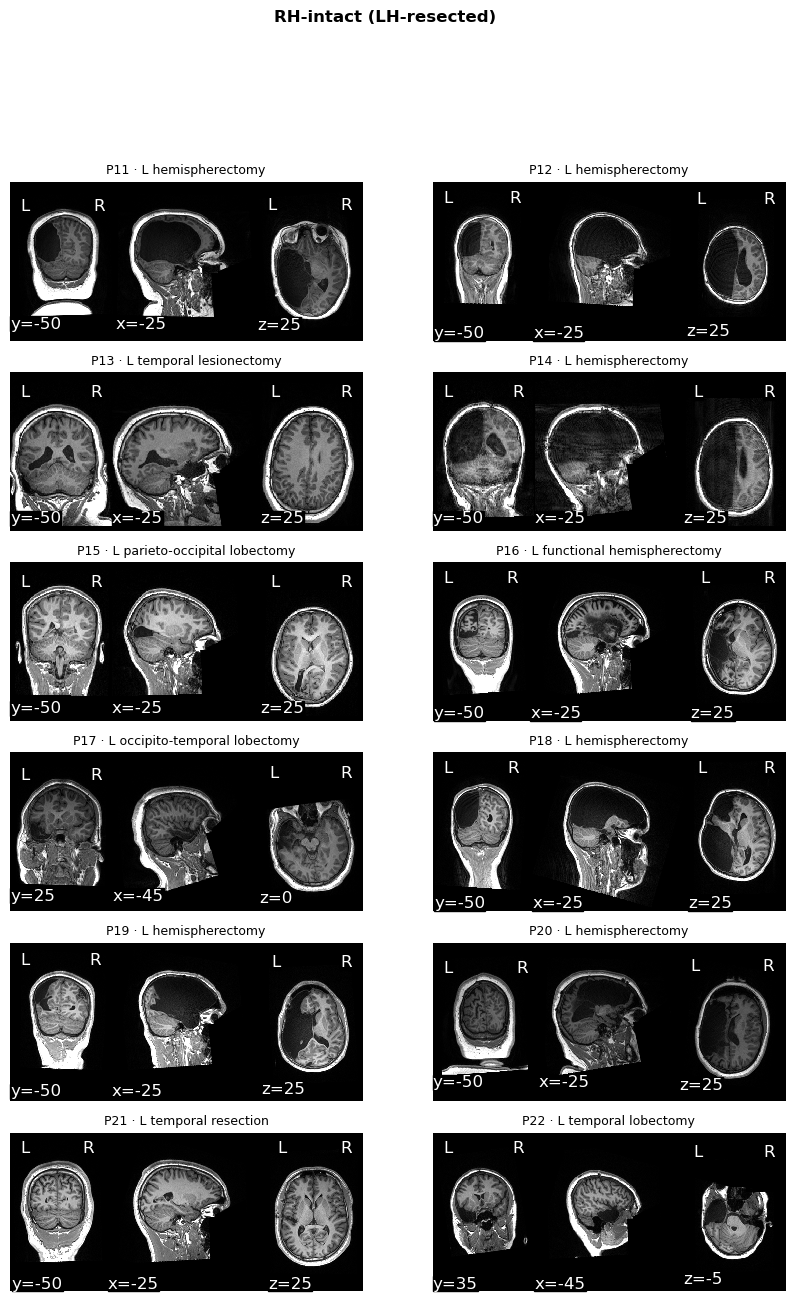

In [7]:
#!/usr/bin/env python
"""
Anatomy figure: most-recent T1 per patient, two panels (LH-intact / RH-intact).
Modeled on the ptoc plotting code. CORRECTED COHORT (sub-076 = RH-intact).
RUN ON THE CLUSTER (reads T1s from RAW_DIR). Tune CUT_COORDS per patient as needed.

Cut defaults to the *resected* hemisphere (opposite of intact) so the cavity is visible.
"""
import os
import matplotlib.pyplot as plt
from nilearn import image, plotting

# ---- paths: adjust if your T1s live elsewhere ----
RAW_DIR = "/lab_data/behrmannlab/hemi/Raw"          # sym_pt raw BIDS
SES = "ses-01"                                       # first session
ANAT_TMPL = "{raw}/{sub}/{ses}/anat/{sub}_{ses}_T1w.nii.gz"
FIG_DIR = "/user_data/csimmon2/git_repos/sym_pt/C_results/figures"
DIM = -1.25

# (public_id, sub_bids, intact_hemi, title)
LH = [  # LH-intact (RH-resected)
    ("P01","sub-077","left","P01 · R hemispherectomy"),
    ("P02","sub-004","left","P02 · R occipito-temporal lobectomy"),
    ("P03","sub-075","left","P03 · R temporal lobectomy"),
    ("P04","sub-074","left","P04 · R hemispherectomy"),
    ("P05","sub-008","left","P05 · R hemispherectomy"),
    ("P06","sub-079","left","P06 · R occipito-temporal ablation"),
    ("P07","sub-039","left","P07 · R temporal lobectomy"),
    ("P08","sub-089","left","P08 · R temporo-parietal lobectomy"),
    ("P09","sub-005","left","P09 · R parieto-occipital resection"),
    ("P10","sub-091","left","P10 · R hemispherectomy"),
]
RH = [  # RH-intact (LH-resected)
    ("P11","sub-099","right","P11 · L hemispherectomy"),
    ("P12","sub-069","right","P12 · L hemispherectomy"),
    ("P13","sub-044","right","P13 · L temporal lesionectomy"),
    ("P14","sub-010","right","P14 · L hemispherectomy"),
    ("P15","sub-021","right","P15 · L parieto-occipital lobectomy"),
    ("P16","sub-090","right","P16 · L functional hemispherectomy"),
    ("P17","sub-076","right","P17 · L occipito-temporal lobectomy"),
    ("P18","sub-108","right","P18 · L hemispherectomy"),
    ("P19","sub-066","right","P19 · L hemispherectomy"),
    ("P20","sub-092","right","P20 · L hemispherectomy"),
    ("P21","sub-082","right","P21 · L temporal resection"),
    ("P22","sub-078","right","P22 · L temporal lobectomy"),
]

# Per-patient cut coords (x,y,z). Seeded from your ptoc figure where available; fill the rest.
CUT_COORDS = {
    "sub-077": (-25, 25, 25), "sub-079": (25, 15, 15), "sub-075": (-25, 25, -15),
    "sub-004": (-25, -25, -15), "sub-089": (25, -45, -15), "sub-076": (-45, 25, 0),
    "sub-078": (-45, 35, -5),
}
def default_cut(intact):
    # show the resected hemisphere
    x = -25 if intact == "right" else 25
    return (x, -50, 25)

def panel(rows, title, outfile):
    n = len(rows); ncol = 2; nrow = -(-n // ncol)
    fig, ax = plt.subplots(nrow, ncol, figsize=(10, 2.4*nrow), facecolor="w")
    ax = ax.ravel()
    for i, (pid, sub, intact, ttl) in enumerate(rows):
        path = ANAT_TMPL.format(raw=RAW_DIR, sub=sub, ses=SES)
        if not os.path.exists(path):
            ax[i].text(0.5, 0.5, f"{pid}\n(T1 not found)", ha="center", va="center"); ax[i].axis("off"); continue
        anat = image.load_img(path)
        cut = CUT_COORDS.get(sub, default_cut(intact))
        plotting.plot_anat(anat, cut_coords=cut, draw_cross=False, dim=DIM, axes=ax[i])
        ax[i].set_title(ttl, fontsize=9)
    for j in range(n, len(ax)): ax[j].axis("off")
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.0)
    os.makedirs(FIG_DIR, exist_ok=True)
    fig.savefig(f"{FIG_DIR}/{outfile}", dpi=300, bbox_inches="tight")
    print("saved", f"{FIG_DIR}/{outfile}")

panel(LH, "LH-intact (RH-resected)", "anatomy_LH_intact.png")
panel(RH, "RH-intact (LH-resected)", "anatomy_RH_intact.png")

saved /user_data/csimmon2/git_repos/sym_pt/C_results/figures/anatomy_LH_intact.png


/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/nilearn/image/resampling.py:809: UserWarning: Casting data from int32 to float32
  return resample_img(


saved /user_data/csimmon2/git_repos/sym_pt/C_results/figures/anatomy_RH_intact.png


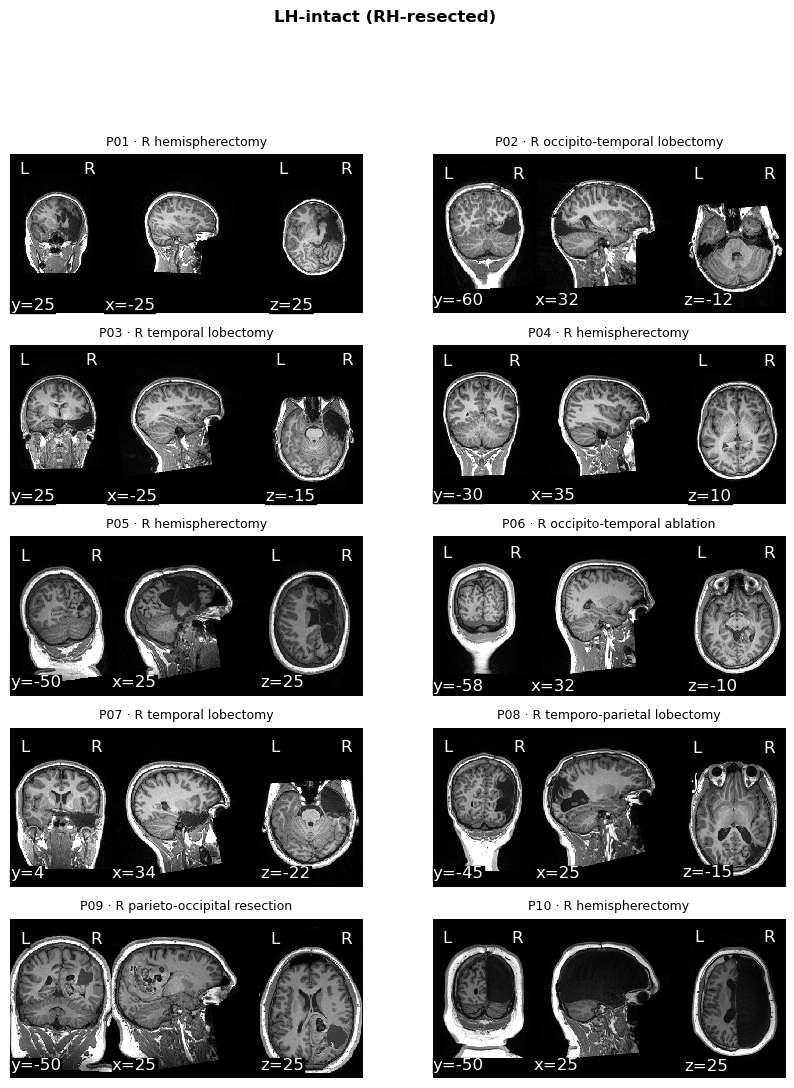

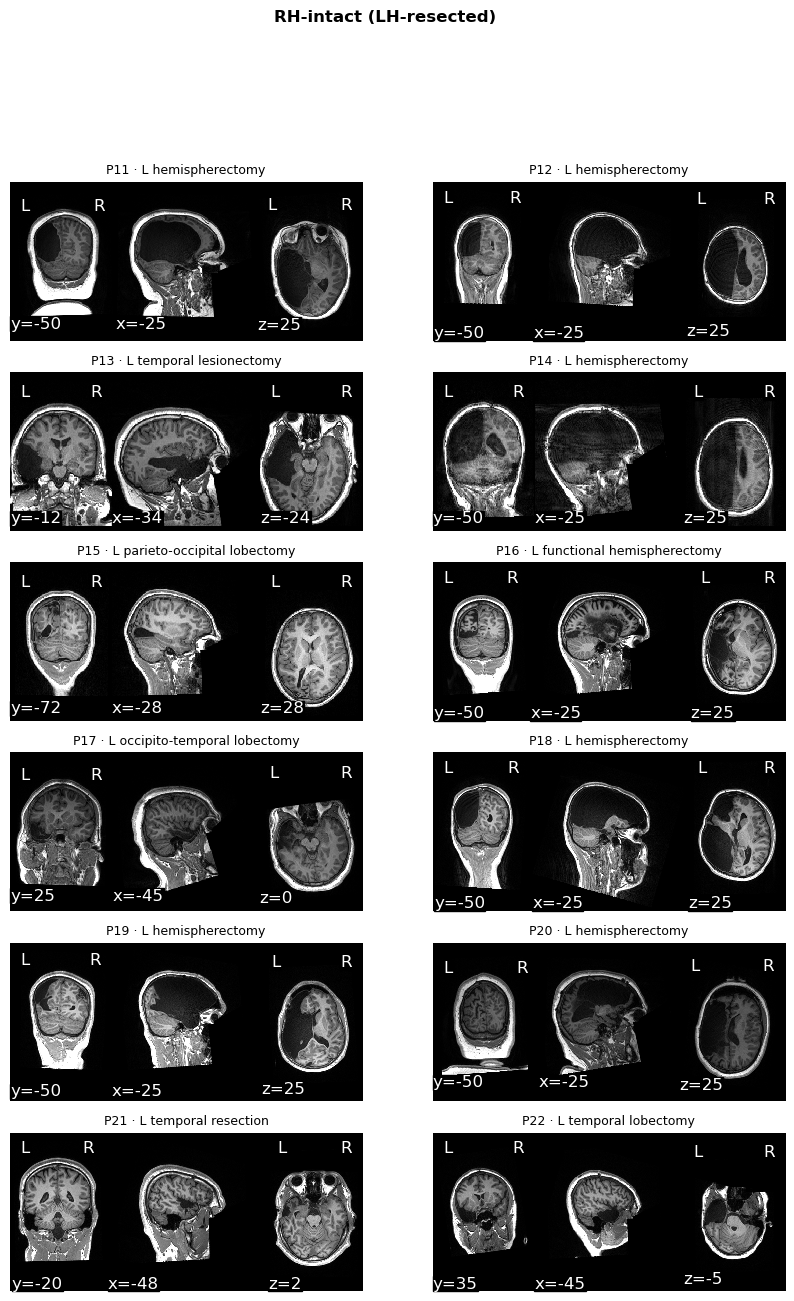

In [9]:
#!/usr/bin/env python
"""
Anatomy figure: most-recent T1 per patient, two panels (LH-intact / RH-intact).
Modeled on the ptoc plotting code. CORRECTED COHORT (sub-076 = RH-intact).
RUN ON THE CLUSTER (reads T1s from RAW_DIR). Tune CUT_COORDS per patient as needed.

Cut defaults to the *resected* hemisphere (opposite of intact) so the cavity is visible.
"""
import os
import matplotlib.pyplot as plt
from nilearn import image, plotting

# ---- paths: adjust if your T1s live elsewhere ----
RAW_DIR = "/lab_data/behrmannlab/hemi/Raw"          # sym_pt raw BIDS
SES = "ses-01"                                       # first session
ANAT_TMPL = "{raw}/{sub}/{ses}/anat/{sub}_{ses}_T1w.nii.gz"
FIG_DIR = "/user_data/csimmon2/git_repos/sym_pt/C_results/figures"
DIM = -1.25

# (public_id, sub_bids, intact_hemi, title)
LH = [  # LH-intact (RH-resected)
    ("P01","sub-077","left","P01 · R hemispherectomy"),
    ("P02","sub-004","left","P02 · R occipito-temporal lobectomy"),
    ("P03","sub-075","left","P03 · R temporal lobectomy"),
    ("P04","sub-074","left","P04 · R hemispherectomy"),
    ("P05","sub-008","left","P05 · R hemispherectomy"),
    ("P06","sub-079","left","P06 · R occipito-temporal ablation"),
    ("P07","sub-039","left","P07 · R temporal lobectomy"),
    ("P08","sub-089","left","P08 · R temporo-parietal lobectomy"),
    ("P09","sub-005","left","P09 · R parieto-occipital resection"),
    ("P10","sub-091","left","P10 · R hemispherectomy"),
]
RH = [  # RH-intact (LH-resected)
    ("P11","sub-099","right","P11 · L hemispherectomy"),
    ("P12","sub-069","right","P12 · L hemispherectomy"),
    ("P13","sub-044","right","P13 · L temporal lesionectomy"),
    ("P14","sub-010","right","P14 · L hemispherectomy"),
    ("P15","sub-021","right","P15 · L parieto-occipital lobectomy"),
    ("P16","sub-090","right","P16 · L functional hemispherectomy"),
    ("P17","sub-076","right","P17 · L occipito-temporal lobectomy"),
    ("P18","sub-108","right","P18 · L hemispherectomy"),
    ("P19","sub-066","right","P19 · L hemispherectomy"),
    ("P20","sub-092","right","P20 · L hemispherectomy"),
    ("P21","sub-082","right","P21 · L temporal resection"),
    ("P22","sub-078","right","P22 · L temporal lobectomy"),
]

# Per-patient cut coords (x,y,z). Seeded from your ptoc figure where available; fill the rest.
CUT_COORDS = {
    # --- unflagged seeds (capturing OK) ---
    "sub-077": (-25, 25, 25), "sub-075": (-25, 25, -15),
    "sub-089": (25, -45, -15), "sub-076": (-45, 25, 0), "sub-078": (-45, 35, -5),
    # --- flagged: lobe-typed STARTING guesses, tune against the scan ---
    "sub-004": ( 32, -60, -12),   # P02  R occipito-temporal  (was on wrong/left side)
    "sub-074": ( 35, -30,  10),   # P04  R hemispherectomy
    "sub-079": ( 32, -58, -10),   # P06  R occipito-temporal
    "sub-039": ( 34,   4, -22),   # P07  R temporal (anterior)
    "sub-044": (-34, -12, -24),   # P13  L temporal
    "sub-021": (-28, -72,  28),   # P15  L parieto-occipital
    "sub-082": (-48, -20,   2),   # P21  L temporal (superior)
}
def default_cut(intact):
    # show the resected hemisphere
    x = -25 if intact == "right" else 25
    return (x, -50, 25)

def panel(rows, title, outfile):
    n = len(rows); ncol = 2; nrow = -(-n // ncol)
    fig, ax = plt.subplots(nrow, ncol, figsize=(10, 2.4*nrow), facecolor="w")
    ax = ax.ravel()
    for i, (pid, sub, intact, ttl) in enumerate(rows):
        path = ANAT_TMPL.format(raw=RAW_DIR, sub=sub, ses=SES)
        if not os.path.exists(path):
            ax[i].text(0.5, 0.5, f"{pid}\n(T1 not found)", ha="center", va="center"); ax[i].axis("off"); continue
        anat = image.load_img(path)
        cut = CUT_COORDS.get(sub, default_cut(intact))
        plotting.plot_anat(anat, cut_coords=cut, draw_cross=False, dim=DIM, axes=ax[i])
        ax[i].set_title(ttl, fontsize=9)
    for j in range(n, len(ax)): ax[j].axis("off")
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.0)
    os.makedirs(FIG_DIR, exist_ok=True)
    fig.savefig(f"{FIG_DIR}/{outfile}", dpi=300, bbox_inches="tight")
    print("saved", f"{FIG_DIR}/{outfile}")

panel(LH, "LH-intact (RH-resected)", "anatomy_LH_intact.png")
panel(RH, "RH-intact (LH-resected)", "anatomy_RH_intact.png")

In [10]:
#!/usr/bin/env python
"""
Coordinate tuner — run interactively (notebook) to find cut coords for the
flagged patients, then paste results into CUT_COORDS in patient_anatomy_figure.py.

Two modes per subject:
  (A) auto-suggest from the resected-hemisphere mask centroid (good for hemispherectomy)
  (B) interactive ortho view you scroll to read coords (good for focal/lobar)
"""
import numpy as np, nibabel as nib
from nilearn import image, plotting

RAW_DIR = "/lab_data/behrmannlab/hemi/Raw"
SES = "ses-01"
T1  = "{raw}/{sub}/{ses}/anat/{sub}_{ses}_T1w.nii.gz"
MASK= "{raw}/{sub}/{ses}/anat/{sub}_{ses}_T1w_brain_mask_{hemi}.nii.gz"  # resected hemi

# flagged subjects: (sub, resected_hemi)
FLAGGED = [("sub-004","Right"),("sub-074","Right"),("sub-079","Right"),
           ("sub-039","Right"),("sub-044","Left"),("sub-021","Left"),("sub-082","Left")]

def centroid_world(mask_path):
    img = image.load_img(mask_path); d = img.get_fdata() > 0
    if d.sum()==0: return None
    ijk = np.array(np.where(d)).mean(axis=1)
    return tuple(np.round(image.coord_transform(*ijk, img.affine), 0))

for sub, hemi in FLAGGED:
    t1 = T1.format(raw=RAW_DIR, sub=sub, ses=SES)
    mp = MASK.format(raw=RAW_DIR, sub=sub, ses=SES, hemi=hemi)
    try:
        c = centroid_world(mp)
        print(f"{sub}: resected-{hemi} mask centroid (world) = {c}")
    except Exception as e:
        print(f"{sub}: no mask ({e})")
    # interactive: scroll to the cavity, read the coords shown, paste into CUT_COORDS
    plotting.view_img(t1, bg_img=t1, threshold=0).open_in_browser() if False else None
    # in a notebook, instead just do:  plotting.plot_anat(t1, dim=-1)  and read cross coords

sub-004: no mask (File not found: '/lab_data/behrmannlab/hemi/Raw/sub-004/ses-01/anat/sub-004_ses-01_T1w_brain_mask_Right.nii.gz')
sub-074: no mask (File not found: '/lab_data/behrmannlab/hemi/Raw/sub-074/ses-01/anat/sub-074_ses-01_T1w_brain_mask_Right.nii.gz')
sub-079: no mask (File not found: '/lab_data/behrmannlab/hemi/Raw/sub-079/ses-01/anat/sub-079_ses-01_T1w_brain_mask_Right.nii.gz')
sub-039: no mask (File not found: '/lab_data/behrmannlab/hemi/Raw/sub-039/ses-01/anat/sub-039_ses-01_T1w_brain_mask_Right.nii.gz')
sub-044: no mask (File not found: '/lab_data/behrmannlab/hemi/Raw/sub-044/ses-01/anat/sub-044_ses-01_T1w_brain_mask_Left.nii.gz')
sub-021: no mask (File not found: '/lab_data/behrmannlab/hemi/Raw/sub-021/ses-01/anat/sub-021_ses-01_T1w_brain_mask_Left.nii.gz')
sub-082: no mask (File not found: '/lab_data/behrmannlab/hemi/Raw/sub-082/ses-01/anat/sub-082_ses-01_T1w_brain_mask_Left.nii.gz')
